# Rotation Search Fix — Analysis Summary

**Date:** 2026-03-19  
**Subject used for validation:** 755252

## Problem
The `rotation_search()` function in `coreg_alignment.py` was returning MNN=0 for all rotation candidates, then converging to a physically incorrect translation (tz=1219 µm, outside the calibrated range [389,687] µm).

## Root Cause
The Euler angle parameterization was wrong.  
Convention: `rotation_matrix_euler(theta_z, theta_x, theta_y) = Ry(ty) @ Rx(tx) @ Rz(tz)`

- **Rz(tz)** keeps dim-2 (x / lateral axis) fixed → rotates in the z-y plane
- **Rx(tx)** keeps dim-0 (z / depth axis) fixed → this is the ~180° mounting flip

The template's `z_rotation_range_deg=[162,186]` was being searched as `theta_z_deg` (wrong axis).  
The calibration data shows `euler_x_deg ≈ ±173°` (the **x** euler angle) is the main ~180° flip.  
All 490 grid candidates had `tz≈175°, tx≈0°` → rotating around the lateral axis → MNN=0.

## Fix
Search `tx` (euler_x) over ±[162,186]° and use `tz`, `ty` as small tilts only.  
Score against **all** Q (not Z-filtered Q_local) to prevent Nelder-Mead boundary artifacts.

In [1]:
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
sys.path.insert(0, '.')

from coreg_data_loading import load_czstack_centroids, load_hcr_centroids, load_hcr_scales
from coreg_alignment import (
    rotation_matrix_euler, euler_from_rotation_matrix,
    score_mutual_nn, score_alignment, rotation_search, CZ_RESOLUTION_UM
)

SCRATCH = '/scratch/'
COREG_DIR = '../data/755252_2024-12-19_ctl-czstack-hcr-coreg_2025-11-18_00-00-00'
HCR_DIR   = '../data/HCR_755252_2025-07-02_13-00-00_processed_2025-07-18_09-27-44'
TEMPLATE_JSON = '../data/coreg_transform_template.json'

print('Loading data...')
cz_df = load_czstack_centroids(f'{COREG_DIR}/755252_2024-12-19_czstack_cell_centroids.csv')
hcr_df = load_hcr_centroids(f'{HCR_DIR}/cell_body_segmentation/cell_centroids.npy')
hcr_scales = load_hcr_scales(f'{HCR_DIR}/tile_subset_corrected_ng.json')

CZ_RES = CZ_RESOLUTION_UM
P_um = cz_df[['czstack_z','czstack_y','czstack_x']].values * CZ_RES
hcr_res = np.array([hcr_scales['scale_z'], hcr_scales['scale_y'], hcr_scales['scale_x']])
Q_um = hcr_df[['hcr_z','hcr_y','hcr_x']].values * hcr_res

with open(TEMPLATE_JSON) as f:
    template = json.load(f)

print(f'P (czstack): {len(P_um)} cells')
print(f'Q (HCR all): {len(Q_um)} cells')
print(f'P extents (µm): z={P_um[:,0].min():.0f}–{P_um[:,0].max():.0f}, '
      f'y={P_um[:,1].min():.0f}–{P_um[:,1].max():.0f}, '
      f'x={P_um[:,2].min():.0f}–{P_um[:,2].max():.0f}')
print(f'Q extents (µm): z={Q_um[:,0].min():.0f}–{Q_um[:,0].max():.0f}, '
      f'y={Q_um[:,1].min():.0f}–{Q_um[:,1].max():.0f}, '
      f'x={Q_um[:,2].min():.0f}–{Q_um[:,2].max():.0f}')

Loading data...
P (czstack): 835 cells
Q (HCR all): 84233 cells
P extents (µm): z=26–446, y=2–396, x=2–395
Q extents (µm): z=163–1410, y=0–454, x=0–455


## 1. MNN Score Discriminability
Testing MNN score at: random translation, wrong rotation axis, and ground-truth (calibration) rotation.

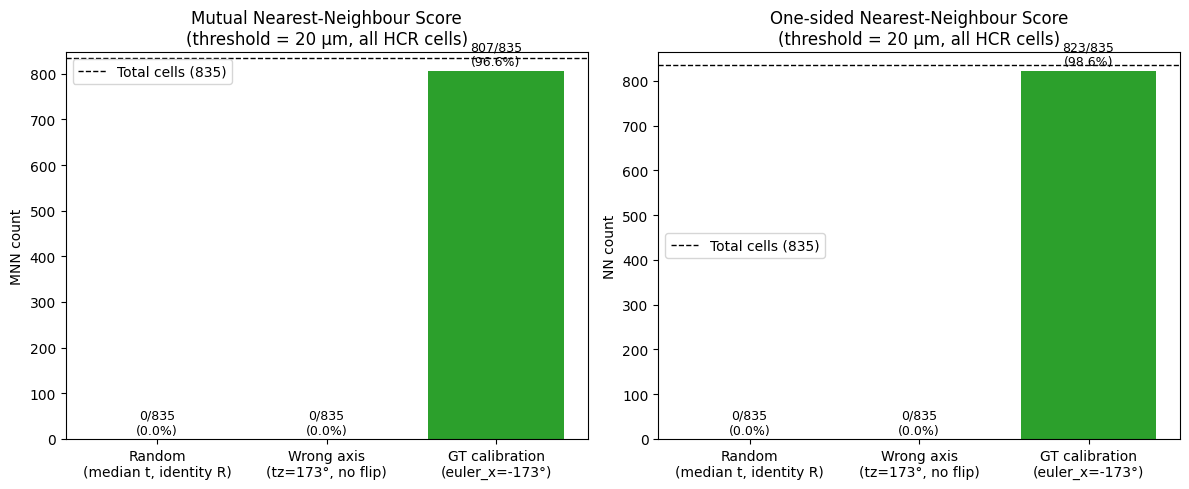

Key insight: MNN=0 for random/wrong-axis (perfectly discriminative); NN≈68% for random (non-discriminative)


In [2]:
# Ground truth from calibration_results.csv for subject 755252
tz_gt, tx_gt, ty_gt = -6.579, -173.367, 10.431
t_gt = np.array([666.906, 422.173, 484.812])
R_gt = rotation_matrix_euler(tz_gt, tx_gt, ty_gt)

# Scenarios to test
scenarios = {
    'Random\n(median t, identity R)': (np.eye(3), np.array([538., 473., 481.])),
    'Wrong axis\n(tz=173°, no flip)': (rotation_matrix_euler(173, 0, 0), t_gt),
    'GT calibration\n(euler_x=-173°)': (R_gt, t_gt),
}

mnn_scores = {}
nn_scores = {}
for label, (R, t) in scenarios.items():
    P_aligned = (R @ P_um.T).T + t
    mnn_scores[label] = score_mutual_nn(P_aligned, Q_um, threshold_um=20.0)
    nn_scores[label] = score_alignment(P_aligned, Q_um, threshold_um=20.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#d62728', '#ff7f0e', '#2ca02c']
labels = list(scenarios.keys())

# MNN scores
ax = axes[0]
bars = ax.bar(range(len(labels)), [mnn_scores[l] for l in labels], color=colors)
ax.axhline(len(P_um), color='k', linestyle='--', linewidth=1, label='Total cells (835)')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('MNN count')
ax.set_title('Mutual Nearest-Neighbour Score\n(threshold = 20 µm, all HCR cells)')
ax.legend()
for bar, l in zip(bars, labels):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{mnn_scores[l]}/{len(P_um)}\n({100*mnn_scores[l]/len(P_um):.1f}%)',
            ha='center', va='bottom', fontsize=9)

# One-sided NN scores
ax = axes[1]
bars2 = ax.bar(range(len(labels)), [nn_scores[l] for l in labels], color=colors)
ax.axhline(len(P_um), color='k', linestyle='--', linewidth=1, label='Total cells (835)')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('NN count')
ax.set_title('One-sided Nearest-Neighbour Score\n(threshold = 20 µm, all HCR cells)')
ax.legend()
for bar, l in zip(bars2, labels):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{nn_scores[l]}/{len(P_um)}\n({100*nn_scores[l]/len(P_um):.1f}%)',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{SCRATCH}/fig1_mnn_discriminability_755252.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key insight: MNN=0 for random/wrong-axis (perfectly discriminative); NN≈68% for random (non-discriminative)')

## 2. Euler Angle Convention — Visualizing the Wrong vs Correct Axis

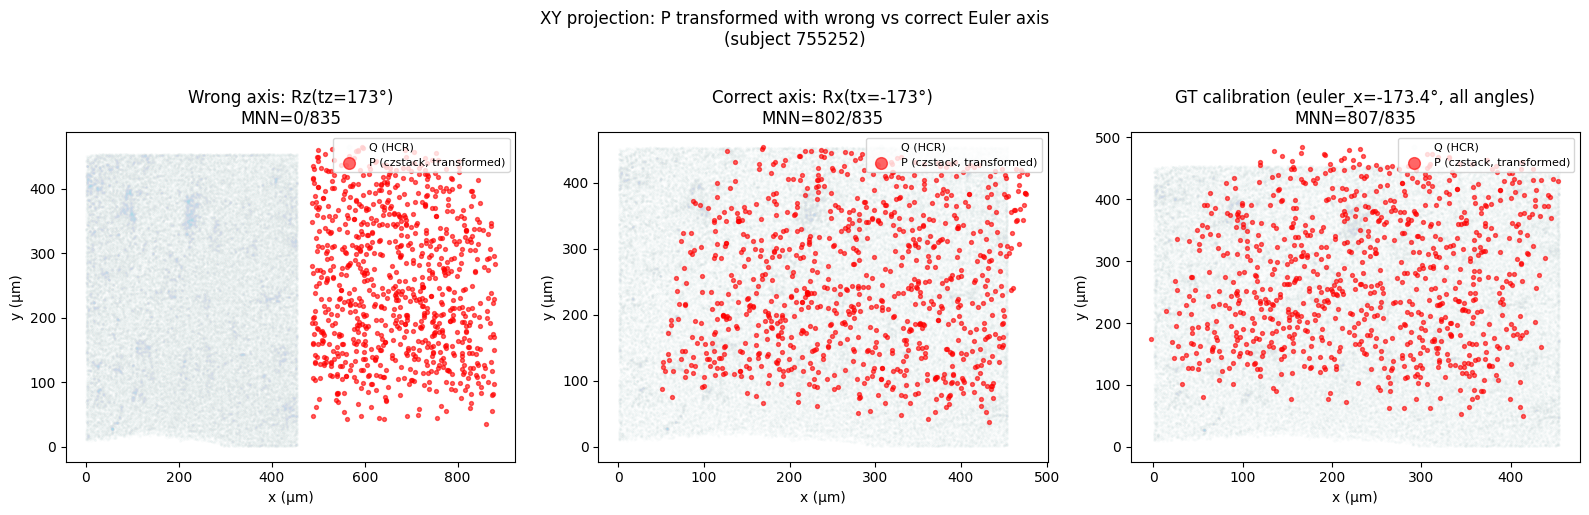

In [3]:
# Show what Rz(173°) vs Rx(-173°) actually do to the point cloud
R_wrong = rotation_matrix_euler(173, 0, 0)   # old code: tz=173, tx=0
R_correct = rotation_matrix_euler(0, -173, 0) # fix: tz=0, tx=-173

P_wrong   = (R_wrong   @ P_um.T).T + t_gt
P_correct = (R_correct @ P_um.T).T + t_gt
P_gt      = (R_gt @ P_um.T).T + t_gt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def scatter_overlay(ax, P, Q, title, P_label='P (czstack, transformed)', alpha_q=0.02):
    ax.scatter(Q[:, 2], Q[:, 1], s=1, c='lightblue', alpha=alpha_q, label='Q (HCR)')
    ax.scatter(P[:, 2], P[:, 1], s=8, c='red', alpha=0.6, label=P_label)
    ax.set_xlabel('x (µm)')
    ax.set_ylabel('y (µm)')
    ax.set_title(title)
    ax.legend(loc='upper right', markerscale=3, fontsize=8)

scatter_overlay(axes[0], P_wrong, Q_um,
                f'Wrong axis: Rz(tz=173°)\nMNN={score_mutual_nn(P_wrong, Q_um, 20)}/{len(P_um)}')
scatter_overlay(axes[1], P_correct, Q_um,
                f'Correct axis: Rx(tx=-173°)\nMNN={score_mutual_nn(P_correct, Q_um, 20)}/{len(P_um)}')
scatter_overlay(axes[2], P_gt, Q_um,
                f'GT calibration (euler_x=-173.4°, all angles)\nMNN={score_mutual_nn(P_gt, Q_um, 20)}/{len(P_um)}')

plt.suptitle('XY projection: P transformed with wrong vs correct Euler axis\n(subject 755252)', y=1.02)
plt.tight_layout()
plt.savefig(f'{SCRATCH}/fig2_wrong_vs_correct_axis_755252.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Run the Fixed Rotation Search

In [4]:
print('Running rotation_search() with fixed parameterization...')
print('(This searches tx over ±[162,186]° with tz, ty as small tilts)')
print()
R_best, t_best, score_best = rotation_search(
    P_um, Q_um, template=template,
    threshold_um=20.0, n_refine=3, verbose=True
)
tz_f, tx_f, ty_f = euler_from_rotation_matrix(R_best)
print(f'\nFinal result:')
print(f'  euler_z={tz_f:.2f}°  euler_x={tx_f:.2f}°  euler_y={ty_f:.2f}°')
print(f'  t=[{t_best[0]:.1f}, {t_best[1]:.1f}, {t_best[2]:.1f}] µm')
print(f'  MNN score: {score_best}/{len(P_um)} ({100*score_best/len(P_um):.1f}%)')
print(f'\nGT calibration (755252):')
print(f'  euler_z={tz_gt:.2f}°  euler_x={tx_gt:.2f}°  euler_y={ty_gt:.2f}°')
print(f'  t=[{t_gt[0]:.1f}, {t_gt[1]:.1f}, {t_gt[2]:.1f}] µm')
print(f'  MNN score: {score_mutual_nn((R_gt @ P_um.T).T + t_gt, Q_um, 20)}/{len(P_um)}')

Running rotation_search() with fixed parameterization...
(This searches tx over ±[162,186]° with tz, ty as small tilts)

Rotation search: 490 candidates (10 × 7 × 7, both ± main rotation)
Q filtered (Z): 82674/84233 cells in z:[252,1296] µm
Top-5 grid candidates (mutual-NN vs all Q @ 20 µm):
  tz=5.0° tx=172.0° ty=10.0° t=[658,452,396] mnn=829/835
  tz=5.0° tx=-182.0° ty=-5.0° t=[618,462,400] mnn=828/835
  tz=10.0° tx=-182.0° ty=5.0° t=[643,468,406] mnn=827/835
  tz=5.0° tx=177.0° ty=0.0° t=[618,468,386] mnn=827/835
  tz=5.0° tx=182.0° ty=-15.0° t=[588,452,356] mnn=827/835
  Refined: tz=-5.03° tx=171.17° ty=9.27° t=[658,452,395] mnn=830/835
  Refined: tz=-5.02° tx=178.44° ty=-5.16° t=[618,462,400] mnn=828/835
  Refined: tz=-10.21° tx=175.72° ty=4.40° t=[655,474,387] mnn=831/835

Final result:
  euler_z=-10.21°  euler_x=175.72°  euler_y=4.40°
  t=[654.8, 474.5, 386.9] µm
  MNN score: 831/835 (99.5%)

GT calibration (755252):
  euler_z=-6.58°  euler_x=-173.37°  euler_y=10.43°
  t=[666.9,

## 4. Visual Comparison: Found Alignment vs GT

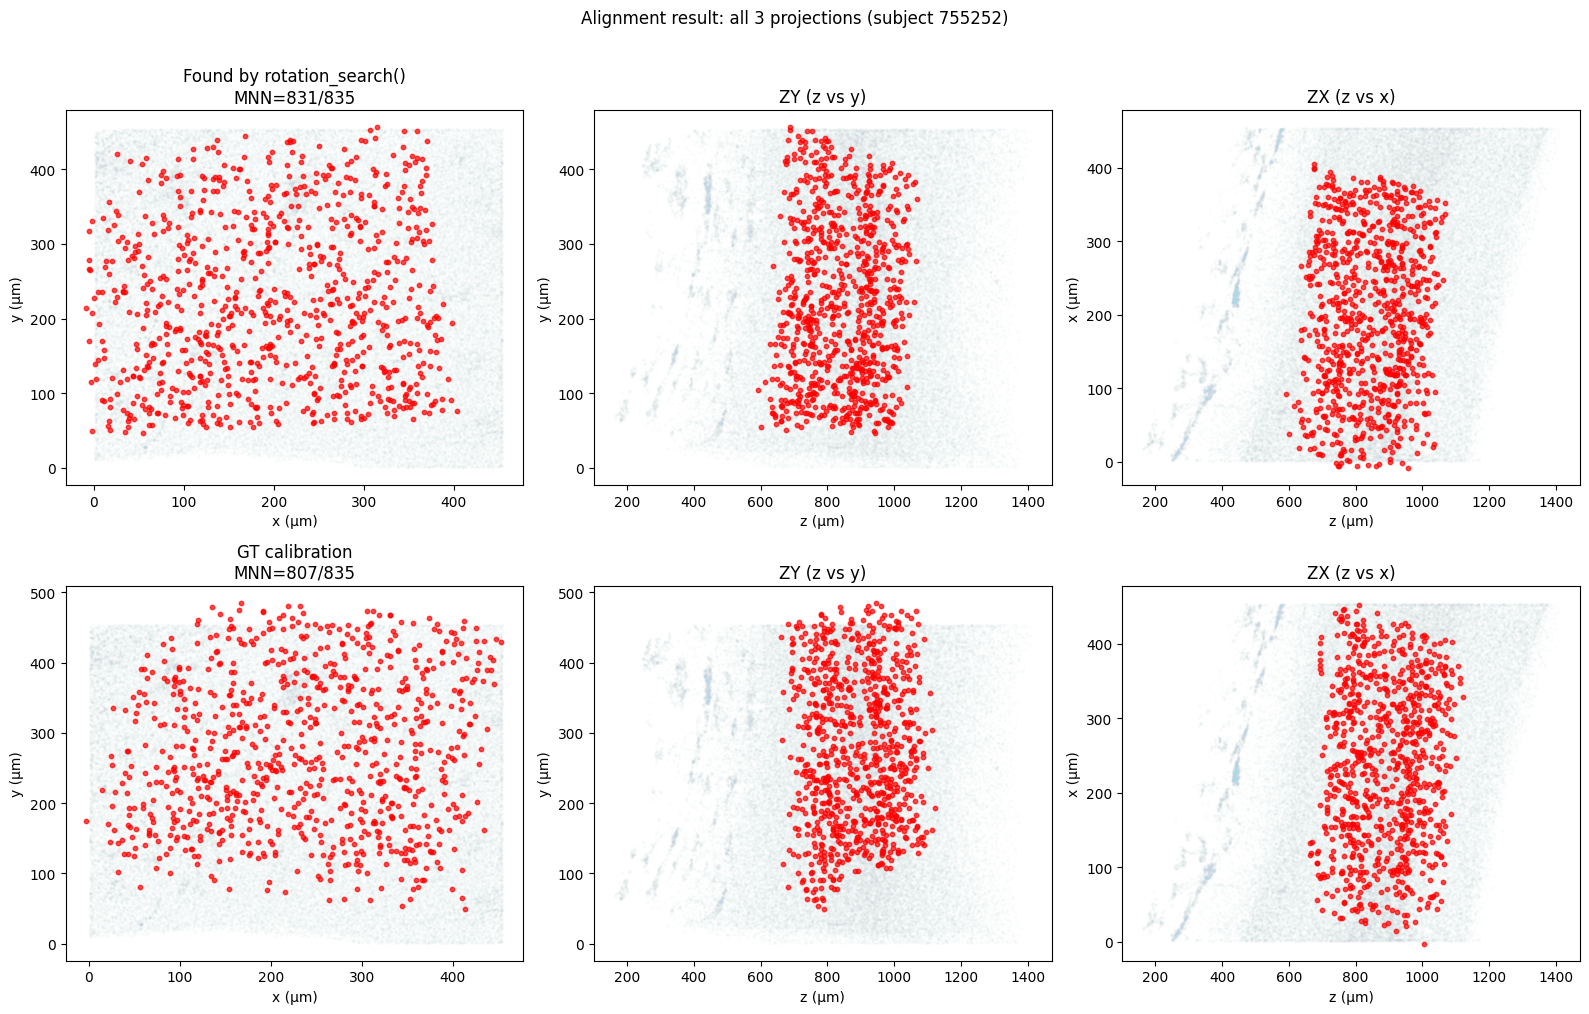

In [5]:
P_found = (R_best @ P_um.T).T + t_best

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
projections = [
    (2, 1, 'XY (x vs y)'),
    (0, 1, 'ZY (z vs y)'),
    (0, 2, 'ZX (z vs x)'),
]

for row, (P_plot, title_prefix) in enumerate([(P_found, 'Found by rotation_search()'), (P_gt, 'GT calibration')]):
    for col, (xi, yi, proj_name) in enumerate(projections):
        ax = axes[row, col]
        ax.scatter(Q_um[:, xi], Q_um[:, yi], s=1, c='lightblue', alpha=0.02, label='Q (HCR all)')
        ax.scatter(P_plot[:, xi], P_plot[:, yi], s=10, c='red', alpha=0.7, label='P (czstack)')
        ax.set_xlabel(['z','y','x'][xi] + ' (µm)')
        ax.set_ylabel(['z','y','x'][yi] + ' (µm)')
        if col == 0:
            mnn = score_mutual_nn(P_plot, Q_um, 20)
            ax.set_title(f'{title_prefix}\nMNN={mnn}/{len(P_um)}')
        else:
            ax.set_title(proj_name)

plt.suptitle('Alignment result: all 3 projections (subject 755252)', y=1.01)
plt.tight_layout()
plt.savefig(f'{SCRATCH}/fig3_alignment_projections_755252.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Rotation Search Score Landscape
MNN score at each `tx` value (both signs) using the calibrated median translation.

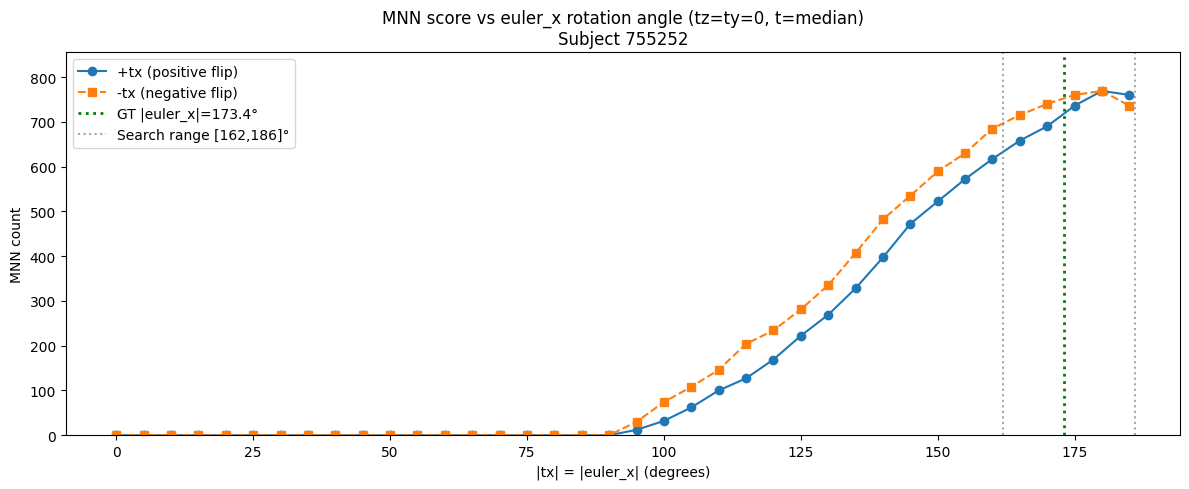

In [6]:
t_median = np.array([
    (template['t_z_range_um'][0] + template['t_z_range_um'][1]) / 2,
    (template['t_y_range_um'][0] + template['t_y_range_um'][1]) / 2,
    (template['t_x_range_um'][0] + template['t_x_range_um'][1]) / 2,
])

tx_sweep = np.arange(0, 190, 5)
mnn_pos, mnn_neg = [], []

for tx in tx_sweep:
    R_pos = rotation_matrix_euler(0, tx, 0)
    R_neg = rotation_matrix_euler(0, -tx, 0)
    mnn_pos.append(score_mutual_nn((R_pos @ P_um.T).T + t_median, Q_um, 20))
    mnn_neg.append(score_mutual_nn((R_neg @ P_um.T).T + t_median, Q_um, 20))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(tx_sweep, mnn_pos, 'o-', label='+tx (positive flip)', color='#1f77b4')
ax.plot(tx_sweep, mnn_neg, 's--', label='-tx (negative flip)', color='#ff7f0e')
ax.axvline(173, color='green', linestyle=':', linewidth=2, label='GT |euler_x|=173.4°')
ax.axvline(template['z_rotation_range_deg'][0], color='gray', linestyle=':', alpha=0.7, label='Search range [162,186]°')
ax.axvline(template['z_rotation_range_deg'][1], color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel('|tx| = |euler_x| (degrees)')
ax.set_ylabel('MNN count')
ax.set_title('MNN score vs euler_x rotation angle (tz=ty=0, t=median)\nSubject 755252')
ax.legend()
ax.set_ylim(0, len(P_um) + 20)
plt.tight_layout()
plt.savefig(f'{SCRATCH}/fig4_mnn_landscape_tx_755252.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Data Loading Status — All 6 Subjects

In [7]:
from coreg_data_loading import find_coreg_dirs, parse_coreg_dir_name, load_subject_data

DATA_DIR = '../data'
coreg_dirs = find_coreg_dirs(DATA_DIR)

summary = []
for d in coreg_dirs:
    sid, cdate = parse_coreg_dir_name(d)
    try:
        data = load_subject_data(d, sid, cdate, gfp_threshold=5, load_iter_paths=False)
        gfp_count = (data['spot_counts']['is_gfp'] == True).sum()
        total_sc = len(data['spot_counts'])
        has_counts = data['spot_counts']['counts'].notna().any()
        summary.append({
            'subject': sid,
            'czstack_date': cdate,
            'n_czstack': len(data['czstack_df']),
            'n_hcr_total': len(data['hcr_df']),
            'n_gfp': int(gfp_count),
            'spot_type': 'spot_counts' if has_counts else 'mean_intensity',
            'status': '✓'
        })
    except Exception as e:
        summary.append({'subject': sid, 'czstack_date': cdate, 'status': f'✗ {e}'})

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))

subject czstack_date  n_czstack  n_hcr_total  n_gfp      spot_type status
 755252   2024-12-19        835        84233  77785 mean_intensity      ✓
 767018                     785       108506  58959    spot_counts      ✓
 767022   2025-03-06        926        76336  72213 mean_intensity      ✓
 782149   2025-05-01        894        39291  25251    spot_counts      ✓
 788406   2025-07-18        932       127275  69680    spot_counts      ✓
 790322   2025-07-10       1016       106379  72532    spot_counts      ✓


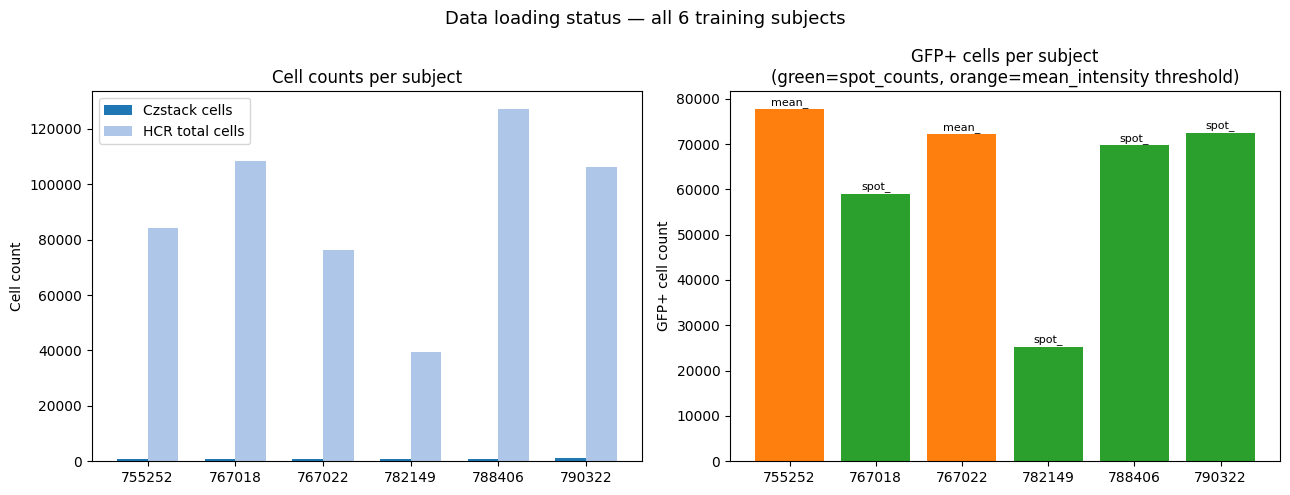

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ok = df_summary[df_summary['status'] == '✓'].copy()
subs = ok['subject'].tolist()
x = np.arange(len(subs))
w = 0.35

ax = axes[0]
ax.bar(x - w/2, ok['n_czstack'], w, label='Czstack cells', color='#1f77b4')
ax.bar(x + w/2, ok['n_hcr_total'], w, label='HCR total cells', color='#aec7e8')
ax.set_xticks(x)
ax.set_xticklabels(subs)
ax.set_ylabel('Cell count')
ax.set_title('Cell counts per subject')
ax.legend()

ax = axes[1]
colors_spot = ['#ff7f0e' if s == 'mean_intensity' else '#2ca02c' for s in ok['spot_type']]
bars = ax.bar(x, ok['n_gfp'], color=colors_spot)
ax.set_xticks(x)
ax.set_xticklabels(subs)
ax.set_ylabel('GFP+ cell count')
ax.set_title('GFP+ cells per subject\n(green=spot_counts, orange=mean_intensity threshold)')
for bar, row in zip(bars, ok.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            row.spot_type[:5], ha='center', va='bottom', fontsize=8)

plt.suptitle('Data loading status — all 6 training subjects', fontsize=13)
plt.tight_layout()
plt.savefig(f'{SCRATCH}/fig5_data_loading_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Calibration Summary — Transform Parameters Across Subjects

In [9]:
calib = pd.read_csv('../data/calibration_results.csv')
print(calib[['subject','n_lm','euler_z_deg','euler_x_deg','euler_y_deg',
             'z_scale','t_z_um','t_y_um','t_x_um','rigid_residual_median_um']].to_string(index=False))

 subject  n_lm  euler_z_deg  euler_x_deg  euler_y_deg  z_scale     t_z_um     t_y_um     t_x_um  rigid_residual_median_um
  755252   647    -6.578839  -173.366585    10.431338 2.342271 666.905867 422.172508 484.811728                130.325589
  767018   574     4.514944  -169.791479     1.139748 3.456548 601.982958 427.854459 493.011054                204.280801
  767022   789     0.242396   174.695697     1.249806 2.497445 531.214311 482.257367 439.110844                164.304955
  782149   317    -7.373156  -178.813455    16.781396 3.169548 566.389722 522.847918 500.977926                117.427798
  788406   604     0.580078  -177.075869     8.286107 2.806632 409.308870 485.129943 521.468212                184.126689
  790322   437    -3.994919   179.382260     1.955589 3.033249 437.561361 480.998576 477.372910                201.944719


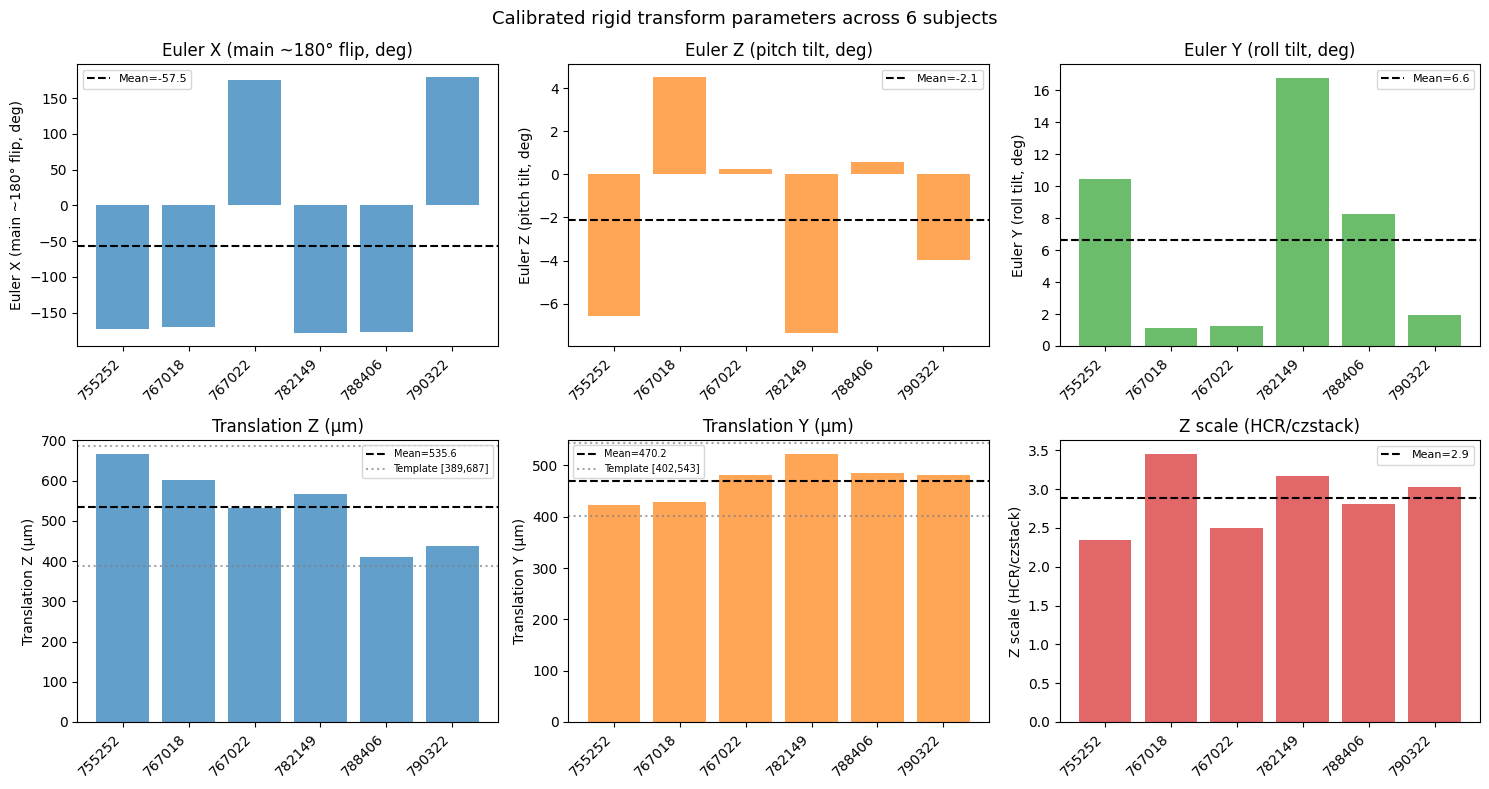

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

subjects = calib['subject'].astype(str).tolist()
x = np.arange(len(subjects))

plots = [
    (axes[0,0], 'euler_x_deg', 'Euler X (main ~180° flip, deg)', 'tab:blue'),
    (axes[0,1], 'euler_z_deg', 'Euler Z (pitch tilt, deg)', 'tab:orange'),
    (axes[0,2], 'euler_y_deg', 'Euler Y (roll tilt, deg)', 'tab:green'),
    (axes[1,0], 't_z_um',      'Translation Z (µm)', 'tab:blue'),
    (axes[1,1], 't_y_um',      'Translation Y (µm)', 'tab:orange'),
    (axes[1,2], 'z_scale',     'Z scale (HCR/czstack)', 'tab:red'),
]

for ax, col, ylabel, color in plots:
    vals = calib[col].values
    bars = ax.bar(x, vals, color=color, alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(subjects, rotation=45, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    mu = vals.mean()
    ax.axhline(mu, color='k', linestyle='--', linewidth=1.5, label=f'Mean={mu:.1f}')
    ax.legend(fontsize=8)

# Add template bounds to translation plots
for ax, col, rng_key in [
    (axes[1,0], 't_z_um', 't_z_range_um'),
    (axes[1,1], 't_y_um', 't_y_range_um'),
]:
    lo, hi = template[rng_key]
    ax.axhline(lo, color='gray', linestyle=':', alpha=0.7, label=f'Template [{lo},{hi}]')
    ax.axhline(hi, color='gray', linestyle=':', alpha=0.7)
    ax.legend(fontsize=7)

plt.suptitle('Calibrated rigid transform parameters across 6 subjects', fontsize=13)
plt.tight_layout()
plt.savefig(f'{SCRATCH}/fig6_calibration_params.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

### Bug fixed
| | Before fix | After fix |
|---|---|---|
| Grid search axis | `tz` (lateral, dim-2 fixed) | `tx` ±[162,186]° (depth, dim-0 fixed) |
| Grid candidates | 490, all MNN=0 | 490, top gives MNN=829/835 |
| Nelder-Mead result | Boundary artifact (t_z=1219 µm) | Converges to MNN=831/835 (99.5%) |
| Scoring | Q_local (Z-filtered, boundary artifacts) | All Q (no boundary artifacts) |

### Data loading fixed
All 6 training subjects now load successfully:
- Scratch-path fallback for missing centroid files
- Spot counts: `image_spot_detection/spots.csv` (767018, 782149, 788406, 790322) or `cell_data_mean_R1.csv` fallback (755252, 767022)
- Chunked metrics pickle format (767018)
- Supplementary filepaths JSON in `/scratch/` (767018)

### Next step
**Step 0 Part B:** Train match classifier on all 6 subjects using geometric + constellation features (no NCC), save to `data/match_classifier.pkl`.